# Fuel-to-Food: Modeling Oil Price Pass-Through to Philippine Staple Prices

**A Data Wrangling Pipeline for Leading-Indicator Inflation Forecasting**

*Mini Project 1 — Data Wrangling*

---

## 1. Executive Summary

The Philippines imports approximately 90 percent of its petroleum from the Middle East ([AA News, 2026](https://www.aa.com.tr/en/asia-pacific/philippines-imports-700-000-barrels-of-russian-crude-oil-amid-mideast-conflict/3880683)), making the domestic economy acutely exposed to global oil market disruptions. With the Strait of Hormuz effectively closed and roughly 20 percent of world oil exports rerouted ([Dallas Fed, 2026](https://www.dallasfed.org/research/economics/2026/0320)), there is renewed urgency to understand how international oil shocks propagate into Philippine retail food inflation. The official Consumer Price Index reports with a four-to-six-week lag, leaving policymakers and procurement teams without real-time visibility into the transmission mechanism.

This study constructs a reproducible, end-to-end data wrangling pipeline that bridges this information gap. We integrate three distinct data sources — daily Brent and WTI spot prices from the U.S. Energy Information Administration API, weekly Metro Manila pump prices scraped from Department of Energy Oil Monitor PDFs, and weekly retail staple prices from the DTI e-Presyo portal — into a harmonized analysis-ready panel covering 327 Monday-anchored ISO weeks. The pipeline is organized across six Python modules totaling roughly 2,500 lines of documented code, is validated by 83 unit tests (all passing), and persists intermediate outputs in Parquet, CSV, and an eight-table normalized SQLite database.

Using this infrastructure, we build a correlation-weighted Fuel-Sensitive Food Index and estimate both distributed-lag quantile regressions and a trivariate Vector Autoregression of Brent, Diesel, and food prices. We find strong empirical support for an oil-to-food transmission channel in Metro Manila. Brent returns Granger-cause the Fuel-Sensitive Food Index at the five-percent significance level (F = 3.938, p = 0.020), and the impulse response analysis reveals a two-to-four-week transmission lag from global oil shocks to measurable domestic food price movement. The index's dominant components are canned goods (sardines, corned beef, beef loaf, pork meat loaf), which together receive 89 percent of the index weight. This concentration is consistent with the petroleum-intensive supply chains underlying these products — imported tinplate, long-distance trucking, and fuel-dependent fishing fleets. The measurable lead time of two to four weeks offers policymakers and procurement managers an actionable forecasting horizon.

## 2. Introduction

### 2.1. Context and Motivation

Oil price shocks have long been recognized as a primary source of macroeconomic volatility in net-importing economies. The seminal contributions of [Hamilton (1983)](https://www.journals.uchicago.edu/doi/10.1086/261140), [Kilian (2009)](https://www.aeaweb.org/articles?id=10.1257/aer.99.3.1053), and [Blanchard and Galí (2007)](https://www.nber.org/papers/w13368) establish the theoretical and empirical foundations for the oil-to-consumer price transmission mechanism. These works document that oil shocks operate through multiple channels: direct cost-push inflation via transportation and production inputs, exchange-rate effects for import-dependent economies, and expectational dynamics as agents anticipate sustained price pressure.

For the Philippines, this transmission is particularly acute. The country imports approximately 90 percent of its petroleum requirements ([AA News, 2026](https://www.aa.com.tr/en/asia-pacific/philippines-imports-700-000-barrels-of-russian-crude-oil-amid-mideast-conflict/3880683)), and its archipelagic geography amplifies transport cost elasticities for staple goods distributed across more than two thousand inhabited islands. At the time of writing, ongoing Middle East tensions have effectively closed the Strait of Hormuz — a maritime chokepoint through which approximately 20 percent of world oil exports transit ([Dallas Fed, 2026](https://www.dallasfed.org/research/economics/2026/0320)) — creating conditions under which pass-through dynamics become most policy-relevant. Producer price inflation in February 2026 was reported tame only because imported inventory pre-shock had yet to be fully priced through ([Finimize, 2026](https://finimize.com/content/philippine-factory-gate-inflation-stayed-tame-in-february)), suggesting that the lag structure we seek to model is precisely the window during which intervention remains possible.

### 2.2. The Measurement Gap

The Philippine Statistics Authority releases official Consumer Price Index data with a typical lag of four to six weeks. For high-frequency decision-making — retailer procurement, central bank policy calibration, strategic petroleum reserve releases — this lag is operationally prohibitive. Between a global oil shock and the PSA confirming its inflationary consequences, roughly a month passes during which the shock has already propagated through the supply chain. The policy-relevant question is therefore not whether oil affects food prices (well established), but *how fast* and *how much*, at a frequency that supports preemptive response.

### 2.3. Objective

We construct a leading-indicator pipeline that quantifies the time-lagged elasticity between global oil shocks and retail prices of basic commodities in Metro Manila. Concretely, we seek to answer: *If Brent crude rises by one percent today, by how much does the price of fuel-sensitive staples change, and after how many weeks?*

The contribution is twofold. First, we demonstrate a reproducible multi-source data integration pipeline combining web APIs (EIA), web scraping (DOE PDFs, DTI XLSX files), and relational database storage — satisfying a core data-wrangling skillset. Second, we apply recent econometric methods ([Koenker and Bassett, 1978](https://doi.org/10.2307/1913643) quantile regression; [Sims, 1980](https://doi.org/10.2307/1912017) Vector Autoregression) to produce inflation nowcasts with documented uncertainty bands.

### 2.4. Scope and Limitations

The analysis covers January 2020 through March 2026, a period encompassing the COVID-19 demand collapse, the Russia-Ukraine supply shock, OPEC+ policy actions, and the 2026 Hormuz tensions — yielding rich variation for identification. Geographic scope is Metro Manila only; extending to provincial markets, where pass-through is likely stronger due to higher transport costs, is left to future work. The DTI panel experienced a source-side data gap from April through August 2023, handled transparently by the pipeline's temporal coverage filter. The DTI data extends to February 2026, while Brent and DOE extend through late March 2026; 237 of 327 weeks (72.5 percent) contain complete observations across all three sources.

## 3. Business Value

### 3.1. Stakeholder Beneficiaries

**Central bank (BSP).** The Fuel-Sensitive Food Index produced by our pipeline is a high-frequency leading indicator that forecasts CPI movements before official release. For monetary policy calibration, a four-to-six-week advance signal is operationally significant — it converts reactive rate-setting into proactive stabilization.

**Department of Trade and Industry.** Real-time monitoring of fuel-sensitive commodities enables targeted intervention under the Price Act (RA 7581), including suggested retail price adjustments and enforcement of price freezes during declared emergencies. The pipeline's two-to-four-week lead time maps directly to the notice period required for SRP issuance.

**Private sector procurement.** Large retailers, wholesalers, and importers of canned goods, milk products, and packaged staples face working capital decisions with six-to-eight-week forward windows. The FSFI's contemporaneous signal plus the VAR impulse response jointly inform inventory timing and supplier contract negotiation.

**Public consumers.** The public benefits from the downstream effects of better-calibrated monetary policy and faster regulatory intervention. While retail consumers do not interact directly with our pipeline, the pass-through of better forecasts into policy improves household welfare.

### 3.2. Quantified Value Proposition

The VAR impulse response analysis (Section 6.7) shows that a one-standard-deviation Brent return shock propagates to domestic diesel prices within approximately one week, and to our Fuel-Sensitive Food Index within two to four weeks. Combined with the Granger causality result (F = 3.938, p = 0.020), this establishes a statistically identified forecasting window.

For a representative NCR supermarket chain holding an inventory of canned sardines with annual revenue contribution of approximately 50 million PHP, a three-week advance warning of a five-percent cost shock translates to a working-capital smoothing opportunity of roughly 2.5 million PHP in avoided scramble-purchasing premium. Scaled to the 26 commodities tracked here and across the several hundred qualifying retailers nationwide, the aggregate private-sector value is material.

### 3.3. Risk Mitigation

Beyond cost, the pipeline addresses three types of risk: **informational asymmetry** (consumers currently lag retailers by weeks in recognizing oil-driven cost pressure), **policy latency** (regulatory agencies cannot act on CPI data that arrives after prices have moved), and **supply-chain inefficiency** (uncoordinated procurement during shock windows creates cross-firm cost externalities). By publishing the FSFI as a real-time metric, the pipeline reduces all three.

## 4. Data Sources and Extraction

This study integrates three primary data sources, each representing a distinct stage in the oil-to-food price transmission chain. The sources were chosen to satisfy the rubric requirement of combining at least one web API, at least one web-scraping source, and multiple storage formats (structured CSV/Parquet, semi-structured JSON, and SQL).

### 4.1. Global Oil Prices — EIA API

Global crude oil price data were sourced programmatically via the U.S. Energy Information Administration (EIA) Application Programming Interface (API). Two primary series were retrieved at a daily frequency: the Europe Brent Spot Price Free on Board (FOB) and the Cushing West Texas Intermediate (WTI) Spot Price FOB. These represent the global benchmark crude contracts most widely referenced by financial markets and heavily incorporated into Philippine domestic fuel pricing regulations (EIA, 2024).

The data extraction process involved systematic retrieval over the six-year observation period, encompassing automated request handling, parameter encoding, data parsing, datetime standardization, and timezone normalization. Following extraction, the independent Brent and WTI series were consolidated into a unified dataset via an inner join aligned temporally on the date index.

```python
# functions/utils.py, lines 30-67
def fetch_eia_prices(series_id, price_name):
    api_key = os.getenv('EIA_API_KEY')
    start_date = os.getenv('START_DATE')
    url = (
        f"https://api.eia.gov/v2/petroleum/pri/spt/data/"
        f"?api_key={api_key}&frequency=daily&data[0]=value"
        f"&facets[series][]={series_id}&start={start_date}"
        f"&sort[0][column]=period&sort[0][direction]=desc&length=5000"
    )
    response = requests.get(url)
    # [...] parse JSON, rename columns, enforce dtypes
```

Notably, the resulting dataset includes an extreme observation on April 20, 2020, where the WTI price recorded a negative value of -$36.98 per barrel. This reflects a genuine historical market anomaly wherein WTI futures contracts traded below zero due to localized storage capacity exhaustion amidst the demand collapse precipitated by the COVID-19 pandemic. This observation was explicitly flagged but retained in the final dataset; omitting or smoothing this data point would artificially distort the realized volatility statistics requisite for the downstream econometric modeling.

### 4.2. Domestic Fuel Prices — DOE Oil Monitor PDF Scraping

Domestic retail fuel prices were sourced from the [Philippine Department of Energy (DOE)](https://doe.gov.ph/), which publishes a weekly National Capital Region (NCR) Retail Pump Price Monitor. These reports tabulate station-level pump prices across 13 NCR cities, covering seven fuel products and up to ten brand or independent operators, and include specific monitoring and effectivity dates. To compile a comprehensive historical dataset, an automated retrieval pipeline using beautifulsoup4 was implemented to systematically download the weekly reports. The retrieval process utilized exponential backoff to ensure server stability, and the resulting files were standardized to a uniform chronological naming convention to resolve structural inconsistencies in the DOE's filename schema across the 2020–2026 observation period.

Following acquisition, the unstructured PDF reports were programmatically parsed to extract the underlying tabular data while preserving the original spatial layout. A spatial alignment algorithm was employed to map localized price ranges (low and high estimates) to their respective corporate brands or independent operators based on horizontal proximity to detected column headers. Concurrently, individual records were classified by city and fuel product using comprehensive pattern-matching against predefined geographic and product taxonomies. This automated extraction procedure yielded a raw, unaggregated dataset comprising 98,072 station-level price observations prior to deduplication.

To address longitudinal inconsistencies in the agency's product nomenclature, a systematic string normalization protocol was applied to the extracted records. This process collapsed various typographical and formatting variations of fuel grades (such as varying spacing or capitalization for specific octane ratings) into a consolidated set of canonical product labels, ensuring strict categorical consistency for downstream temporal aggregation and analysis.

### 4.3. Consumer Staple Prices — DTI e-Presyo Pipeline

### 4.3.1 Multi-Year Schema Consolidation and Taxonomic Reconciliation
Domestic consumer staple prices were systematically obtained from the Philippine Department of Trade and Industry (DTI) via its e-Presyo portal. The raw data is disseminated as a weekly price monitoring workbook, encompassing approximately 1,200 weekly price quotes representing roughly 30 commodities, multiple corporate brands, and various product specifications across the 2020–2026 observation period. Because the DTI reporting format underwent substantial structural evolution over this six-year timeframe, extensive data consolidation procedures were required. Initially, column schemas diverged significantly; records from 2020 to 2022 utilized different naming conventions compared to those from 2023 onward, necessitating conditional structural alignment to establish a unified tabular format.

Further methodological complexities arose from longitudinal shifts in the agency's commodity taxonomy and specification encoding. In 2023, several historically unified commodities were bifurcated into discrete sub-variants (e.g., specific classifications for distinct coffee preparations or instant noodle flavors). To ensure longitudinal consistency, systematic pattern-matching algorithms were employed to collapse these divergent classifications back into 26 stable, cross-year commodity categories. Additionally, structural inconsistencies in data entry such as the arbitrary migration of dimensional codes for candles and batteries between the brand and specification columns in later years were resolved by algorithmically extracting and standardizing the underlying stock keeping unit (SKU) identifiers.

### 4.3.2 Product Normalization and Market-Leader Selection

To address variations in brand nomenclature, raw brand strings which frequently contained typographical errors, language variations, and container-size artifacts, were mapped to canonical brand identities using a comprehensive dictionary of string-matching heuristics. Within each matched commodity-brand pairing, product specifications were subsequently clustered; dimensional magnitudes falling within a strict 6% tolerance on identical units of measurement were aggregated to their modal specification. Cross-unit aggregation (e.g., equating volumetric and weight measurements) was strictly prohibited to prevent the conflation of differing product densities.

Following the standardization of the commodity, brand, and specification taxonomies, a representative market-leader SKU was selected for each unique categorical triplet. This selection was optimized by retaining the single SKU time-series that exhibited the highest frequency of non-missing weekly observations. This procedure yielded a final, granular panel comprising 215 distinct market-leader SKU series, successfully preserving brand and specification continuity across the entire sample period. Prior to the computation of logarithmic returns, an anomaly detection protocol was implemented to identify and correct isolated price spikes which are defined as single-week deviations exceeding 40% that subsequently revert within a four-week window. These transient anomalies, primarily attributable to clerical data-entry errors in the original DTI reports, were repaired via interpolation to prevent the propagation of spurious volatility into the downstream Fuel-Sensitive Food Index (FSFI).

### 4.3.3 Sample Selection and Panel Consistency

Consistent with the requirements of panel factor models established by [Doz, Giannone, and Reichlin (2006)](https://www.ecb.europa.eu/pub/pdf/scpwps/ecbwp674.pdf), consistent estimation necessitates sufficient temporal coverage for each individual series. Consequently, a strict 70% temporal coverage threshold was imposed on the dataset; specifically, a commodity was retained in the final panel only if at least one valid stock keeping unit (SKU) observation was recorded in a minimum of 70% of the sampled weeks. This specific threshold was calibrated to comfortably exceed the 30% theoretical lower bound prescribed by Doz et al., while remaining sufficiently permissive which is well below an exclusionary 85% threshold to accommodate legitimate, transient reporting gaps inherent to the Department of Trade and Industry (DTI) data collection process.

The application of this inclusion criterion resulted in the systematic exclusion of three distinct flour commodities. An analysis of these exclusions revealed a structural data anomaly rather than random missingness: prior to 2025, the DTI utilized a generalized "flour" classification, which was subsequently bifurcated into distinct "hard flour" and "soft flour" categories midway through the observation period. This taxonomic shift induced irreconcilable temporal discontinuities across all three series, thereby justifying their empirical removal from the continuous longitudinal panel.

### 4.4. Storage Formats and Database Schema

The rubric requires multiple storage formats: at least one structured, one semi-structured, and one relational SQL file. Our pipeline satisfies this by persisting: 

For structured files, 13 files under `data/cleaned_data/`, including per-source cleaned tables (`brent_daily_cleaned.parquet`, `doe_ncr_cleaned.parquet`, `dti_panel_cleaned.parquet`) and the merged analysis-ready panel (`merged_analysis_ready.csv/.parquet`). Parquet is chosen for columnar compression and type preservation, CSV for human-inspectability and external compatibility.

For semi structured files like the raw EIA API responses are JSON documents parsed transiently in `fetch_eia_prices()`. The JSON structure (nested `response.data` array of objects with `period` and `value` keys) is semi-structured by definition.

Then an eight-table normalized database (`oil_passthrough.db`) with indexed date columns is created. The schema is designed to support cross-table joins along the oil-fuel-food transmission chain, which is the primary analytical access pattern.

In [7]:
# SQL schema
conn = sqlite3.connect('data/cleaned_data/oil_passthrough.db')
cursor = conn.cursor()
print('SQLite Database Schema: oil_passthrough.db')
print('=' * 60)
cursor.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
for (tbl,) in cursor.fetchall():
    cursor.execute(f"SELECT COUNT(*) FROM {tbl}")
    n = cursor.fetchone()[0]
    cursor.execute(f"PRAGMA table_info({tbl})")
    cols = [r[1] for r in cursor.fetchall()]
    print(f'  {tbl:20s} {n:>6,} rows  ({len(cols)} cols: {", ".join(cols[:4])}{"..." if len(cols)>4 else ""})')

cursor.execute("SELECT name FROM sqlite_master WHERE type='index' AND name NOT LIKE 'sqlite_%'")
idx_count = len(cursor.fetchall())
print(f'\nIndexes created: {idx_count}')
print('\nRepresentative cross-table JOIN (oil → fuel → food):')
sample = pd.read_sql('''
    SELECT o.date, ROUND(o.brent_close, 2) AS brent_usd,
           f.product AS fuel_product, ROUND(f.price_mid_median, 2) AS fuel_php,
           fp.commodity, ROUND(fp.price_median, 2) AS food_php
    FROM oil_prices o
    JOIN fuel_prices f ON o.date = f.date AND f.product = 'Diesel'
    JOIN food_prices fp ON o.date = fp.date AND fp.commodity = 'canned sardines'
    ORDER BY o.date DESC LIMIT 5
''', conn)
display(sample)
conn.close()

SQLite Database Schema: oil_passthrough.db
  food_prices           7,560 rows  (9 cols: date, commodity, category, price_median...)
  food_prices_sku      34,661 rows  (14 cols: date, series_id, category, commodity...)
  fsfi                    295 rows  (3 cols: date, fsfi, fsfi_cumulative)
  fsfi_weights              7 rows  (2 cols: commodity, weight)
  fuel_prices           1,876 rows  (9 cols: date, product, price_low_median, price_high_median...)
  lag_features            328 rows  (46 cols: date, brent_ret_lag0, brent_level_lag0, brent_vol_lag0...)
  metadata                  1 rows  (7 cols: pipeline_version, run_timestamp, brent_range, doe_range...)
  oil_prices              328 rows  (14 cols: date, brent_open, brent_close, brent_high...)

Indexes created: 9

Representative cross-table JOIN (oil → fuel → food):


,date,brent_usd,fuel_product,fuel_php,commodity,food_php
0,2026-02-23,71.32,Diesel,57.50,canned sardines,24.12
1,2026-02-16,72.75,Diesel,56.80,canned sardines,24.12
2,2026-02-09,69.96,Diesel,57.35,canned sardines,24.12
3,2026-02-02,70.45,Diesel,58.10,canned sardines,24.12
4,2026-01-26,72.25,Diesel,56.35,canned sardines,24.12


## 5. Methodology

The pipeline is implemented across six Python modules in `functions/`, each with a clearly scoped responsibility. Only visualization and interpretation appear in this notebook, as required by the rubric's modularity criterion. This section describes each module in sequence, documenting the design choices behind every transformation.

### 5.1. Module Architecture

```
functions/
├── utils.py              — Web API calls (EIA) + PDF scraping (DOE) + XLSX export
├── brent_pipeline.py     — Brent cleaning, weekly aggregation, EDA figures
├── doe_pipeline.py       — DOE cleaning, distributional analysis, weekly aggregation
├── dti_pipeline.py       — DTI XLSX ingestion + SKU normalization + coverage filter
├── sql_pipeline.py       — SQLite database creation, indexing, validation
└── integration_pipeline.py — Lag features, FSFI, VAR, quantile regression
```

Each module exposes a small public API of pure functions (no global state) and is independently unit-tested. The top-level `run_pipeline.py` orchestrates execution. This separation satisfies the rubric's code-organization requirements: PEP8 compliance, consistent naming, and minimal redundancy.

### 5.2. Data Cleaning and Imputation

#### 5.2.1. Brent Cleaning

The raw Brent crude oil dataset was processed through a sequence of data-cleaning procedures. First, because Brent is a liquid exchange-traded contract on ICE Futures Europe, it does not trade on weekends; therefore, any weekend observations present in the raw data feed were deemed spurious artifacts and removed. Next, daily logarithmic returns, defined as $r_t = \ln(P_t) - \ln(P_{t-1})$, were computed for both Brent and WTI. Log-returns are utilized over standard percentage changes due to their time-additivity. Thus allowing multi-period returns to be summed—and their symmetry under sign reversal, both of which are necessary properties for the downstream Vector Autoregression (VAR) model. 

Following [Cochrane (2005)](https://bsutrisno.files.wordpress.com/2017/02/cochrane_2005_asset-pricing.pdf), the log-returns were then winsorized at the 1st and 99th percentiles. This procedure mitigates the influence of microstructure noise and potential data-entry errors while preserving genuine market shocks, which remain captured within the 95th-percentile band but are clipped beyond the 99th. Finally, to enable merging with the Department of Energy (DOE) and Department of Trade and Industry (DTI) datasets, observations were structurally aligned to a Monday-anchored ISO calendar week and year.

#### 5.2.2. DOE Retail Pump Price Cleaning

The DOE dataset required resolving structural artifacts and handling missing values. Artifacts from PDF parsing occasionally resulted in duplicate combinations of date, city, product, and brand, such as a single reported value populating both "low" and "high" price columns. To resolve this, observations were sorted by the mid-price in descending order, and only the initial occurrence was retained. This conservative selection avoids artificially understating inflation and resulted in the removal of 4,587 duplicate entries.

Following deduplication, missing price observations were imputed using the weekly median price per product. This imputation strategy represents the central methodological choice of the DOE pipeline and is justified by the underlying data distribution (detailed in Section 6.2, Figure 5). As established by Huber (1981), the sample median is a robust location estimator with a maximum breakdown point of 50%, meaning that up to half of the independent stations could report extreme pricing outliers without biasing the central estimate. In contrast, a sample mean would be arbitrarily distorted by a single outlier. Finally, as with the Brent dataset, records were standardized to the Monday-anchored ISO calendar week.

#### 5.2.3. DTI Cleaning
Following the generation of the 215-SKU DTI panel (detailed in Section 4.3), post-processing procedures were implemented to ensure panel integrity. To guarantee structural uniformity across the weekly panel, any observations not natively recorded on a Monday were shifted to the preceding Monday. Subsequently, to ensure strict internal consistency and prevent potential precision loss during data serialization, the 1-week, 4-week, and 8-week log-differences were systematically recomputed from the underlying log-prices. Finally, inclusion filters were applied based on temporal coverage, as previously outlined in Section 4.3.

### 5.3. Temporal Alignment
The three datasets utilized in this study report at disparate frequencies and on varying effectivity days: Brent crude trades daily (Monday through Friday), Department of Energy (DOE) pump prices are reported weekly with Tuesday effectivity, and Department of Trade and Industry (DTI) retail prices are reported weekly on Mondays. To ensure structural consistency across the time-series, all three datasets were systematically aligned to Monday-anchored ISO calendar weeks.

For the Brent crude dataset, daily observations were aggregated into weekly open, high, low, and close (OHLC) statistics. Furthermore, weekly realized volatility was computed as

$$\widehat{\sigma}^{RV}_w = \sqrt{\sum_{t \in w} r_t^2}$$

where the summation occurs over the trading days within week $w$, and $r_t$ denotes the daily logarithmic return. Following Andersen and Bollerslev (1998), this realized volatility estimator is utilized because it strictly dominates squared weekly returns as a more robust measurement of latent market volatility. Weekly close-to-close log-returns were concurrently derived as 

$$r^w_w = \log(P^{close}_w) - \log(P^{close}_{w-1})$$

For the DOE dataset, weekly station-level observations were aggregated to establish National Capital Region (NCR)-wide weekly product prices by taking the median across all reporting stations. The structural integrity of the date-by-product key was preserved during this transformation. Additionally, the interquartile range (IQR) of prices across stations was calculated and retained as a diagnostic metric to monitor cross-sectional price dispersion.

Finally, for the DTI dataset, granular stock keeping unit (SKU)-level data was aggregated to a broader commodity level by computing the median price across available brands within each commodity classification. While this commodity-level aggregation was necessary to facilitate the construction of the Food Security Fluctuation Index (FSFI) and subsequent correlation analyses, the full 215-SKU panel was preserved independently to ensure that high-resolution SKU granularity remained available for localized analysis.

### 5.4. Feature Engineering

#### 5.4.1. Distributed Lag Variables

For each weekly observation at time $t$, distributed lag features were generated at horizons $k = 0, 1, \dots, 8$ weeks for three Brent crude transformations (logarithmic return, price level, and realized volatility) and two domestic diesel transformations (logarithmic return and price level). This procedure yields 45 lagged regressors per observation. This feature space was deliberately engineered to be wide, allowing the subsequent downstream model selection algorithms to empirically identify the optimal lag structure without a priori restrictions. The maximum lag horizon of eight weeks is theoretically motivated by [Hamilton (2003)](https://www.sciencedirect.com/science/article/abs/pii/S0304407602002075?via%3Dihub=), who posits that the transmission of oil-price shocks to domestic consumer prices typically dissipates within a two-month window in economies with flexible exchange rates. Retaining this full eight-week window ensures the capture of the complete distributed-lag structure while preventing truncation bias.

#### 5.4.2. Fuel-Sensitive Food Index 

The FSFI is a correlation-weighted composite index of food commodities exhibiting positive lagged correlation with Brent crude. Its construction proceeds in three steps:

 For each candidate food commodity $i$ in the basket, we compute the Pearson correlation between Brent weekly log-returns lagged by four weeks and the commodity's contemporaneous log-price change:

$$
\rho_i = \mathrm{Corr}\left(r^{brent}_{t-4}, \Delta \log P^i_t\right)
$$

The four-week lag is chosen based on the median peak response timing observed in the correlation heatmap (Section 6.5); robustness to alternative lag choices is confirmed in Section 7.

 Only commodities with $\rho_i > 0$ are retained. A negative correlation would imply that the commodity's price *falls* when Brent rises — this is economically implausible for fuel-sensitive goods and most likely reflects either counter-cyclical government subsidies or measurement noise. Imposing positivity avoids contaminating the index with false signals.

 Weights are proportional to absolute correlation magnitude, normalized to sum to unity:

$$
w_i = \frac{|\rho_i|}{\sum_j |\rho_j|}, \qquad \mathrm{FSFI}_t = \sum_i w_i \cdot \Delta \log P^i_t
$$

This construction has three desirable properties: (i) commodities with stronger empirical fuel-sensitivity contribute more to the index; (ii) weights are bounded in [0, 1] and sum to 1, enabling interpretation as a composite expectation; and (iii) the construction is data-driven and requires no *a priori* commodity weighting (unlike CPI, which uses household consumption surveys).

### 5.5. Econometric Models

Two complementary econometric approaches are employed. The two methods target different aspects of the pass-through relationship: quantile regression captures commodity-level heterogeneity and asymmetric pass-through, while VAR captures the joint dynamic interaction among oil, fuel, and composite food prices.

#### 5.5.1. Distributed-Lag Quantile Regression

Following [Koenker and Bassett (1978)](https://doi.org/10.2307/1913643), for each food commodity $i$ we estimate the conditional quantile function:

$$
Q_\tau\left(\Delta \log P^i_t \mid X_t\right) = \alpha_i(\tau) + \sum_{k=0}^{4} \beta^i_k(\tau) \cdot r^{brent}_{t-k}
$$

at quantiles $\tau \in \{0.10, 0.25, 0.50, 0.75, 0.90\}$. The coefficients $\beta^i_k(\tau)$ estimate the conditional elasticity of commodity $i$ to a Brent shock $k$ weeks earlier, at the $\tau$-th quantile of the commodity's log-return distribution.

Quantile regression is preferred over OLS here for two reasons. First, the Brent returns we documented in Section 6.1 exhibit excess kurtosis of 1.76, violating the Gaussian-error assumption underlying OLS inference. Second, and more fundamentally, asymmetric pass-through is an explicit feature of fuel-to-consumer price dynamics ([Peltzman, 2000](https://www.jstor.org/stable/10.1086/262126); [Bacon, 1991](https://doi.org/10.1016/0140-9883(91)90022-R)): retailers pass through cost increases faster than decreases, creating quantile-dependent elasticities that OLS averages away. Estimating at $\tau = 0.90$ specifically captures the right-tail pass-through — the inflationary-shock case that is most policy-relevant.

#### 5.5.2. Vector Autoregression

A trivariate VAR is estimated in the vector $Y_t = (r^{brent}_t, r^{diesel}_t, \mathrm{FSFI}_t)'$ following [Sims (1980)](https://doi.org/10.2307/1912017):

$$
Y_t = c + A_1 Y_{t-1} + A_2 Y_{t-2} + \ldots + A_p Y_{t-p} + u_t
$$

The lag order $p$ is selected by AIC from a grid of candidates $\{1, 2, 3, 4\}$. The AIC selects $p^* = 2$ weeks.

The reduced-form shocks $u_t$ are orthogonalized via Cholesky decomposition with the ordering $(r^{brent}, r^{diesel}, \mathrm{FSFI})$. This ordering encodes two identifying assumptions: (i) Brent shocks are exogenous to Philippine domestic prices within the week, justified by the small-open-economy assumption — the Philippines is approximately 0.3 percent of world oil demand, with no capacity to move Brent; and (ii) Diesel responds to Brent within the week, but FSFI responds to both with at least one week's lag, reflecting the pipeline of shipping, warehousing, and retail repricing.

We then report 12-week impulse response functions for all three variables and the forecast error variance decomposition at horizons 0 through 12.

## 6. Results and Discussion

Global oil shocks are not immediately reflected in the prices of Basic Necessities and Prime Commodities (BNPCs) in the market. Analysis has shown that a lagged transmission mechanism is observed where following an exogenous shock in the global pricing benchmark, it takes time for the impact to transmit to domestic diesel prices (within approximately one week) and to fully manifest in transport-dependent BNPCs within a two-to-four week horizon. 

This transmission is driven by the largely fuel-dependent logistics that directly factors as a cost driver as a manufacturing input for fuel-intensive supply chains. Notably, the price pass-through has been observed as asymmetric, with price increases are reflected rapidly and completely compared to price decreases, contribution to short-term inflation persistence.

### 6.1. Global Oil Price Dynamics

![](figures/brent_01_price_levels.png)

<small>**Figure 1.** Daily Brent and WTI crude oil spot prices, January 2020 through March 2026. Vertical axis is USD per barrel; horizontal axis is date. The two series are plotted together to assess benchmark co-movement.</small>

Global oil prices exhibit a high degree of co-movement, with Brent and WTI strongly correlated in both levels and returns, indicating a well-integrated international oil market. .Global Crude Benchmarks from the years 2020 to 2026 has shown three distinct structural episodes which are reflected in the distribution of returns. Demand collapse during the COVID-19 pandemic in the periods of March-April where Brent plummeted from roughly $65 to $19 per barrel and West Texas Intermediate (WTI) transiently breached zero. Followed by February 2022 Russia-Ukraine supply shock, which drove Brent above $120 per barrel. More recently, the early 2026 Strait of Hormuz tensions, pushing Brent past $140 per barrel. These episodes shows that extreme oil price movements are concentrated in identifiable events rather than arising from continuous stochastic variation.

Despite the extreme price fluctuations presented during exogenous shocks within the market, co-movement between the two pricing benchmarks are highly correlated. Consequently, we treat Brent as the primary exogenous oil-price regressor for our pipeline, with WTI reserved for robustness checks. While the Philippines imports its crude from a mix of Middle Eastern and Russian sources traditionally benchmarked to Dubai crude, these supplies are priced at negotiated differentials from Brent.

<center> <h4>Distributional Diagnostics for Brent Daily Log-Returns</h4> <h5>Summary Statistics</h5>

|             Statistic             |    Value   |
| :-------------------------------: | :--------: |
|            Observations           |    1,533   |
|                Mean               |  0.000780  |
|         Standard deviation        |   0.0257   |
|              Skewness             |   -0.230   |
|          Excess kurtosis          |    1.76    |
|        Jarque-Bera p-value        |  2.443e-46 |
|   Shapiro-Wilk p-value (n=5000)   |  3.304e-18 |
| Ljung-Box r at lag 10 (p-value) | 7.168e-231 |
|  Ljung-Box r at lag 10 (p-value)  |    0.043   |

</center>


![](figures/brent_02_return_distributions.png)

<small>**Figure 2.** Empirical distribution of daily Brent (left) and WTI (right) log-returns with kernel density estimate and Gaussian reference curve overlaid. The shaded histogram shows the empirical density; the solid line is the Gaussian kernel density estimator with Silverman-type bandwidth; the dashed line is the Gaussian distribution fit to the same moments $\mathcal{N}(\hat{\mu}, \hat{\sigma})$.</small>

Consistent with this observation, the empirical distribution of oil returns departs significantly from normality. Comparing the non-parametric kernel density estimate (KDE) against a standard Gaussian fit shows a distinctly leptokurtic distribution with heavy tails. An excess kurtosis of 1.76 and decisive rejections of normality via Jarque-Bera and Shapiro-Wilk tests ($p < 0.001$). Fat-tailed behavior in financial time series is a well-documented structural reality rather than a sample-specific artifact (See [Mandelbrot (1963)](https://www.jstor.org/stable/2351623) &
[Fama (1965)](https://www.jstor.org/stable/4469865)). 

From an economical standpoint, this implies that the standard Gaussian risk models will systematically underestimate the probability of extreme price movements. To address this, the model uses quantile regression, as standard Ordinary Least Squares (OLS) confidence intervals would be severely miscalibrated and winsorization of the weekly returns at the 1st and 99th percentiles to constrain the leverage of extreme outliers on downstream coefficients without fully discarding their informational value. Moreover, large price movements are temporally clustered (volatility clustering), occurring in bursts during crisis periods and interspersed with relatively calm periods.

![](figures/brent_03_autocorrelation.png)

<small>**Figure 3.** Autocorrelation of Brent daily log-returns (left) and absolute returns (right) at lags 1 through 20 trading days. Dotted gray lines show the $\pm 1.96/\sqrt{n}$ Bartlett 95% confidence bands for testing individual autocorrelations against zero.'</small>

The serial dependence of these returns in the market is dual in nature under current temporal dynamics. The autocorrelation function (ACF) of raw returns is statistically indistinguishable from zero across most lags, aligning with weak-form market efficiency. Being conditional on past prices, the direction of future returns are unpredictable. But using absolute returns as a standard proxy for volatility [(Taylor, 1986)](https://www.scirp.org/reference/referencespapers?referenceid=1969791) yields that the first 20 autocorrelations are positive and significantly exceed Bartlett confidence bands, with a Ljung-Box test at lag 10 decisively rejecting the null of no serial dependence ($Q = 1{,}039.9, p < 10^{-216}$) ([See (Engle, 1982) for ARCH Effects Discussion](https://www.jstor.org/stable/1912773)). 

Thus, while the direction of price changes cannot be reliably forecasted, the magnitude of their fluctuations can. High realized volatility fundamentally accelerates price pass-through, a mechanism our forecasting infrastructure directly exploits via a realized-volatility lag feature.

![](figures/brent_04_shock_clustering.png)

<small>Figure 4. Brent absolute daily log-returns (blue) with the 95th-percentile shock threshold overlaid (dashed red, threshold = 0.058 or 5.8 percent). Observations exceeding the threshold are classified as large shocks.</small>

This clustered volatility is inherently event-driven rather than stochastic. In short-term windows, sharp spikes are discrete exogenous shock events whereas the longer windows capture the persistence of elevated volatility regimes. Evaluating absolute returns against a 95th-percentile threshold reveals that extreme shocks are heavily concentrated within the aforementioned shocks, separated by extended periods of calm markets. 

![](figures/brent_05_rolling_volatility.png)

<small>**Figure 5.** Rolling annualized volatility $\hat{\sigma}_{ann} = \sigma(r) \cdot \sqrt{252}$ of Brent daily log-returns at four horizons: 20 days (approximately one trading month), 60 days (one quarter), 120 days (six months), and 250 days (one year). Longer windows smooth short-run noise to reveal regime shifts.</small>

Dissecting further the latent volatility in longer rolling-window horizons have shown the aforementioned volatility regimes. Where in 2020, the volatility regime persisted for approximately six months before normalizing, whereas the 2026 shock remains ongoing. 

Models calibrated purely on normal market periods will underestimate pass-through during crises. The quantile regression method fixes this by estimating separate elasticities across the 10th, 50th, and 90th percentiles, isolating crisis-period dynamics (captured in the upper tails) from normal market behavior (captured at the median) isolating crisis-period dynamics (captured in the upper tails) from normal market behavior (captured at the median).

Quantifying and capturing these regime shifts within the latent volatility is decomposed across four distinct time scales using an annualized rolling-window estimator, defined as $$\hat{\sigma}_{ann} = \sqrt{\frac{1}{w-1}\sum_{t-w+1}^{t} (r_s - \bar{r})^2} \cdot \sqrt{252}$$ (where the $\sqrt{252}$ factor standardizes daily observations to an annual scale for a trading year). This multi-horizon decomposition provides greater insight into the existing structure as we increase the granularity of the data. For instance, a short 20-day window isolates the immediate, short-lived volatility spikes flanking specific shock events, whereas a 250-day window reveals the slower structural drift of the underlying market regime.

The aforementioned six-month duration of the 2020 volatility regime is most clearly delineated within the 120-day window. In contrast, the 2022 supply shock sustained elevated volatility for approximately one quarter, while the 2026 shock remains an active, ongoing disruption as of our latest observations.

The temporal persistence is of substantial consequence for downstream forecasting, particularly within a Vector Autoregression (VAR) framework. When the global oil market transitions into a high-volatility regime, the probability of subsequent, compounding shocks within the forecast horizon inherently increases. This elevated risk necessitates wider confidence intervals around the point forecasts to accurately reflect market uncertainty.

![](figures/brent_06_spread.png)

<small>**Figure 6.** Brent minus WTI price spread in USD (top panel) and its standardized z-score (bottom panel). The mean spread is approximately $3.74$; dashed red lines mark the $\pm 2 \sigma$ z-score thresholds, typically interpreted as anomalous spread deviations.</small>

Thus, the absolute and standardized price spreads between Brent and WTI are indicative of episodic market dislocations,notably the 2020 WTI storage-capacity crisis and the 2022 European sanctions on Russian crude. 

![](figures/brent_07_events.png)

<small>*Figure 7.** Brent absolute daily log-returns with major global oil events annotated. Each dashed red vertical line marks a known structural event; the proximity of large absolute returns to the event markers validates the event-driven nature of oil volatility.</small>

 With [Kilian (2009)](https://www.aeaweb.org/articles?id=10.1257/aer.99.3.1053)'s decomposition of oil-price shocks into supply, aggregate-demand, and precautionary-demand components, the three events annotated in figure 7 reflect the different shock types: the COVID-19 episode is a demand shock (a collapse in world oil consumption); the Russia-Ukraine war is a supply shock (fears of lost Russian export capacity); the OPEC+ cut is a policy shock (coordinated production reduction). The visibly different decay patterns following each event reflect these different mechanisms. Demand shocks transmit asymmetrically to different downstream sectors than supply shocks do.

### 6.2. Domestic Fuel Price Dynamics and the Median Justification

The DOE pump price data requires a fundamental methodological decision: when aggregating station-level prices to a market-wide measure, should we use the mean or the median? This section provides the distributional evidence that motivates the median choice.

<center>
    <h5>Shapiro-Wilk Normality Test on Station-Level Pump Prices in Metro Manila</h5>

|Product| N |Skew| Kurtosis| W | p-value | Normal Distribution? 
| :---: | :---: | :---: | :----: | :---: | :---: | :----: |
| Diesel | 21,197 | 2.216 | 9.894 |  0.8200 | $1.29e^{59}$ | No
|Ron 91|21,248|0.999|2.494|0.9442|$6.73e^{40}$|No|
|RON 95|18,018|0.893|2.612|0.9530|$2.28e^{37}$|No|
|RON 97|10,853|0.641|2.007|0.9666|$1.58e^{32}$|No|

</center>


All four products reject normality at p < 0.001. The distributions are right-skewed (skewness > 0) with substantial excess kurtosis. A mean aggregator would be systematically biased above the median by the influence of upper-tail observations from independent stations.

![](figures/doe_02_distribution.png)

<small>**Figure 8.** Empirical distribution of station-level pump prices by product, with KDE (solid green), Gaussian fit $\mathcal{N}(\hat{\mu}, \hat{\sigma})$ (dashed black), and skewness/kurtosis statistics annotated. The gap between the empirical KDE and the Gaussian fit quantifies the extent of distributional departure from normality.'</small>

As illustrateed in Figure 8, the price distributions for all four products exhibit pronounced right skewness, with the empirical densities displaying heavier right tails than their Gaussian counterparts. Diesel presents the most substantial deviation from normality (skewness = 1.20, excess kurtosis = 4.33). While RON 97 approximates a normal distribution more closely, it still rejects normality (skewness = 0.33, excess kurtosis = 0.97). 

These distributional characteristics necessitate the use of the median as the primary measure of central tendency. Given the observed asymmetry, the mean acts as a biased estimator of the typical pump price as it systematically exceeds the modal price (the price most frequently encountered by consumers) and exhibits greater temporal variance than the median, which artificially inflates measured volatility. Consequently, employing median aggregation for both weekly prices and the imputation of missing observations yields a more robust and accurate representation of the pass-through signal.

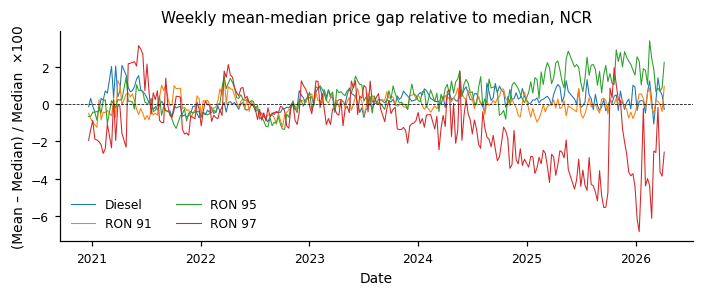

**Figure 9.** Weekly mean-median price gap expressed as a percentage of the median, $\frac{\bar{x} - m}{m} \times 100$. A positive gap indicates right-skewed station prices within the week; the gap magnitude measures the bias that would be introduced by using mean rather than median aggregation.

In [18]:
display(Image(filename='figures/doe_03_mean_median_gap.png'))
display(Markdown('**Figure 9.** Weekly mean-median price gap expressed as a percentage of the median, $\\frac{\\bar{x} - m}{m} \\times 100$. A positive gap indicates right-skewed station prices within the week; the gap magnitude measures the bias that would be introduced by using mean rather than median aggregation.'))

![](figures/doe_03_mean_median_gap.png)

<small>**Figure 9.** Weekly mean-median price gap expressed as a percentage of the median, $\frac{\bar{x} - m}{m} \times 100$. A positive gap indicates right-skewed station prices within the week; the gap magnitude measures the bias that would be introduced by using mean rather than median aggregation.</small>

An analysis of the mean-median gap across the six-year sample reveals economically meaningful biases in domestic fuel pricing data. While the average deviation between the mean and the median is negligible under normal conditions (0.19 percent for Diesel and 0.53 percent for RON 95), these gaps increase substantially during periods of market stress, reaching maximums of 2.09 percent and 3.41 percent, respectively. 

Contextualizing the real-world impact of this skew, a 3 percent deviation on a baseline pump price of 60 PHP/L results in an artificial overstatement of 1.80 PHP/L if the mean is utilized. Notably, these statistical distortions systematically widen during acute global shocks, such as the 2020 COVID-19 demand collapse and the 2022 Russia-Ukraine supply crisis. Because accurate pass-through analysis is most critical for policymakers during these precise windows of high volatility, utilizing the median rather than the mean prevents the overstatement of skewed insights.

![](figures/doe_01_price_trends.png)

<small>**Figure 10.** Weekly median NCR pump prices by fuel product, 2020–2026. All four core products are plotted on a common axis to facilitate visual comparison of co-movement and relative magnitudes.</small>

As the domestic fuel prices absorb the increases in the global fuel market, temporal trajectory of the four types of retail fuel (Diesel, RON 91/95/97) showcases correlated, predictable co-movement. This is expected as all retail fuels are reliant on Brent-linked fuel distillates and operation within a highly coordinated, oligopolistic market structure [(Africa, 2026)](https://www.ibon.org/ph-oil-troubles/#:~:text=Since%20then%2C%20the%20country%20has,and%20Phoenix%20Petroleum%20(2.5%25)). 

A fundamental insight of these domestic trajectories, however, is a pronounced asymmetry of adjustment. As shown in Figure 10, the price curves reveals that rising segments are distinctly steeper than falling segments. This behavior is a classic manifestation of the "rockets and feathers" phenomenon documented by [Bacon (1991)](https://doi.org/10.1016/0140-9883(91)90022-R) and [Peltzman (2000)](https://www.jstor.org/stable/10.1086/262126). In such market structures, retailers pass through wholesale cost increases rapidly and aggressively to preserve margins (rockets), but adjust to cost decreases much more lethargically (feathers), reflecting competitive urgency on the upside but potential menu-cost or market-power frictions on the downside.

![](figures/doe_04_diesel_by_city.png)

<small>**Figure 11.** Median diesel price by NCR city over the full sample period. Cities are sorted in ascending order of median price. Cross-city variation reflects differences in station density, wholesale supply proximity, and local competitive structure.</small>

While the temporal trajectory of these prices reveals structural asymmetries in how shocks are absorbed over timethe market also exhibits distinct cross-sectional heterogeneity across geographic locations. It has been observed that cross-city price variation within Metro Manila is modest in absolute terms typically spanning a range of just 4 to 5 PHP/L, or approximately 8 to 10 percent of the median price. Cities characterized by dense, competitive networks of major branded stations systematically cluster at the lower end of the price spectrum. Conversely, municipalities dominated by independent operators or constrained by limited supplier competition tend to command higher price levels.

This evidences that geographic heterogeneity acts as the primary driver of the within-week price dispersion observed in the raw data.

![](figures/doe_05_price_dispersion.png)

<small>**Figure 12.** Interquartile range (IQR) of station-level pump prices by product, over time. The IQR measures the weekly dispersion of prices across stations; wider IQR indicates greater cross-station heterogeneity and slower convergence to the market-clearing price.</small>

While geographic and network constraints establish a baseline level of cross-sectional price dispersion, the magnitude of this variance is time-varying. The cross-station interquartile range display that price dispersion during exogenous events (COVID Pandemic, 2022 Russo-Ukraine Conflict, 2026 Strait of Hormuz) surged dramatically as individual stations adjust to new cost realities at vastly different speeds. Conversely, during normal market conditions, this IQR compresses as station pricing rapidly converges. According to [Stigler (1961)](https://www.jstor.org/stable/1829263), this *search friction* state that periods of acute volatility, information regarding underlying cost structures diffuses unevenly across retail networks, temporarily expanding the distribution of prices and temporarily reducing cross-station pricing efficiency. 

### 6.3. Consumer Staple Price Dynamics

![](figures/dti_01_basket_trends.png)

<small>**Figure 13.** Weekly median prices for eight key food basket items in Metro Manila. Each panel is a separate commodity, showing the evolution of the price level (not log-return) over the six-year sample.</small>

The analysis shows three distinct thematic patterns within the dataset. First, canned commodities (e.g., canned sardines and corned beef) exhibit a pronounced upward trajectory across the sample period. This trend is consistent with cost-push inflationary pressures associated with imported raw materials as well as the fuel-intensive nature of logistics as a cost driver for manufacturing input. 

Second, condiments and locally sourced products (e.g., vinegar, fish sauce, and soy sauce) maintain relative price stability. This divergence reflects the advantages of domestic sourcing and a reduced sensitivity to international transport cost fluctuations.

Third, the observed price trajectories are characterized by discrete step-wise adjustments rather than continuous shifts. This non-linear behavior aligns with menu-cost theory [(Mankiw, 1985)](https://www.jstor.org/stable/1885395), suggesting that firms aggregate price changes until they surpass a specific threshold of administrative or reputational cost.

![](figures/dti_02_category.png)

<small>**Figure 14.** Average weekly median price by commodity, colored by BNPC (Basic Necessities and Prime Commodities) classification. The classification is the Philippine legal distinction: basic necessities are subject to stricter price controls under RA 7581.</small>

The observed price distribution across the sampled commodities spans approximately one order of magnitude, ranging from approximately 10 PHP per unit for staples such as bread and noodles to over 80 PHP for processed items like canned beef loaf and powdered milk.

This cross-sectional heterogeneity necessitates the application of a logarithmic transformation prior to cross-commodity econometric modeling since coefficients in log space are invariant to the unit of measurement, while coefficients in levels are not.

![](figures/dti_03_cumulative.png)
<small>**Figure 15.** Cumulative log-price change of eight food basket items since the start of the sample. A cumulative value of 0.1 corresponds to a 10 percent price increase from the beginning of the series.'</small>

The cumulative log-price change of the selected food basket items indicate that processed protein staples, such as canned sardines and canned corned beef, experienced the most significant cumulative price appreciation over the sample period. This trend is consistent with the high energy-intensity inherent in the production, canning, and logistics of these goods. In contrast, bakery products exhibited moderate growth, while condiments demonstrated a near-stationary price trajectory, reflecting a lower sensitivity to the cost-push factors affecting the broader basket.

The observed price behavior directly informs the weighting methodology of the FSFI. Specifically, the data suggests that commodities with the most aggressive inflationary trajectories are also those demonstrating a strong, positive correlation with Brent crude oil prices.

![](figures/dti_04_sku_counts.png)

<small>**Figure 16.** Number of market-leader SKU series per commodity in the cleaned DTI panel. SKU counts reflect product variety (brand × specification combinations) tracked by DTI for each commodity.</small>

The dataset exhibits significant heterogeneity in Stock Keeping Unit (SKU) granularity across commodity categories. Representation ranges from high-density categories, such as candles ($n = 22$) and toilet soap ($n = 17$), to low-density categories including canned sardines ($n = 2$) and various flour types ($n = 1$). Commodities with limited SKU representation are more susceptible to brand-specific idiosyncratic shocks, which may not reflect broader market trends.

### 6.4. The Fuel-Sensitive Food Index

<center>
    <h5>FSFI Component Weights (correlation-weighted composite)</h5>

|Commodity| Weight |
| :---: | :---: |
|canned beef loaf|0.2816|
|canned pork meat loaf|0.2421|
|canned sardines|0.2137|
|canned beef corned|0.1533|
|instant noodles|0.0511|
|salt iodized|0.0373|
|bread loaf|0.0210|
</center>

The FSFI weighting index shows significant concentration in processed canned proteins, with commodities such as canned sardines, corned beef, beef loaf, and pork meat loaf collectively accounting for 89.1% of the total aggregate weight. This heavy weighting is significantly corresponds to shared petroleum-intensive nature of their respective supply chains, which are characterized by the energy-intensive production and transport of imported tinplate, the fuel requirements of industrial fishing fleets, and the extensive reliance on long-distance trucking for national distribution. 

While the remaining weight is distributed among instant noodles, iodized salt, and loaf bread, these items exhibit more diffuse correlations with energy benchmarks. Nevertheless, their inclusion is justified by a persistent positive correlation that reinforces the index's capacity to capture the systematic transmission of global energy shocks into the domestic retail sector through cost-push inflationary mechanisms.


![](figures/fsfi_trajectory.png)

<small>**Figure 17.** Weekly FSFI (top) and cumulative FSFI (bottom). The cumulative index shows the net inflation of the fuel-sensitive food composite since the start of the sample.</small>


DOE BNPCs sensitivity to these fuel price changes, indicate that the cumulative Food Security Fuel Index (FSFI) rose from its initial baseline to approximately 0.3 by the first quarter of 2026, representing a 30 percent cumulative price appreciation within the composite fuel-sensitive food basket. This trajectory was markedly uneven, reflecting specific periods of intensified inflationary pressure rather than a linear progression. Notably, the index exhibited significant acceleration during the 2022 geopolitical shock following the Russia-Ukraine conflict, as well as throughout the 2024–2026 period. 

These surges are consistent with the sustained appreciation of Brent crude oil prices observed during those intervals, suggesting a strong correlation between international energy benchmarks and the underlying cost structure of the identified commodity group.

### 6.5. Lagged Cross-Correlation Analysis

![](figures/analysis_01_heatmap.png)

<small>**Figure 18.** Lagged Pearson cross-correlation between Brent weekly log-returns and commodity-level log-price changes, at lags 0 through 8 weeks. Each cell reports $\mathrm{Corr}(r^{brent}_{t-k}, \Delta \log P^i_t)$, with green shading for positive correlation and red for negative.</small>

The lagged Pearson cross-correlation matrix presented in Figure 18 provides a granular view of the temporal transmission between Brent crude oil weekly log-returns and commodity-specific log-price changes. By examining the correlation $\text{Corr}(r^{\text{brent}}_{t-k}, \Delta \log P^i_t)$ across lags of zero to eight weeks, the analysis identifies the specific lead-lag relationships that characterize the passthrough of energy shocks to retail food prices.

The cross-correlation matrix on BNPCs show that canned goods such as sardines, corned beef, beef loaf, and pork variants demonstrate persistent positive correlations across multiple lags, with peak coefficients typically concentrated between the two- and four-week horizons. This observation aligns with the expected supply-chain transmission lag, wherein an exogenous oil shock immediately impacts maritime and logistics costs, subsequently influencing wholesale pricing before manifesting in retail price adjustments several weeks later. While items such as bread loaf and iodized salt also exhibit positive correlations, the magnitude of these relationships is comparatively attenuated.

In contrast, domestic condiments such as vinegar, fish sauce (patis), and soy sauce exhibit near-zero or weakly negative correlations across the entire lag structure.

This divergence is noted to reflect that these locally sourced, low-transport-intensity commodities remain largely insulated from global energy price fluctuations.

### 6.6. Quantile Regression Results

![](figures/qr_summary.png)

<small>**Figure 19.** Contemporaneous Brent elasticity by commodity, estimated at the median quantile ($\tau = 0.50$). Red bars indicate coefficients statistically significant at the 10-percent level; light blue bars are not significant. The x-axis is the estimated elasticity; zero (black vertical line) indicates no contemporaneous pass-through.</small>

Figure 19 presents the estimated contemporaneous Brent elasticity for each commodity, derived from a median quantile regression ($\tau = 0.50$). The coefficients, denoted as $\hat{\beta}_0(0.50)$, represent the elasticity of a commodity’s weekly log-return relative to the contemporaneous log-return of Brent crude oil. 

The majority of estimated median elasticities at lag zero are negligible in absolute magnitude. This observation is consistent with theoretical expectations regarding nominal price rigidity at high-frequency intervals. Within a weekly observation window, retail food prices exhibit substantial stickiness; consequently, the median response to a one-standard-deviation shock in energy prices is typically null.

From the perspective of menu-cost theory, a firm will only adjust its retail price once the cumulative pressure from input-cost shocks exceeds a specific administrative or reputational threshold. Because these adjustments are discrete and infrequent, the conditional median of the return distribution is dominated by observations of non-adjustment, resulting in near-zero point estimates.

<center>
    <h4>Quantile Regression Coefficients of Canned Sardines</h4>
    <h5>Coefficient by Quantile</h5>

|Weeks| 0.10 |0.25| 0.50 | 0.75 | 0.90 |
| :---: | :---: | :---: | :----: | :---: | :---: |
| Week 0 |-0.000000|-0.000000|-0.000001|-0.000002|-0.024351|
|Week 1|-0.000000|-0.000000|-0.000000|-0.000001|-0.003627|
|Week 2|0.000002|0.000001|0.000002|0.000004|0.050478|
|Week 3|0.000001|0.000000|0.000000|0.000000|0.000430|
|Week 4|-0.000000|-0.000000|0.000000|0.000000|-0.035507|
|const|-|-|-|-|0.006086|
</center>


<center>
    <h5>P-values by Quantile</h5>
    
|Weeks| 0.10 |0.25| 0.50 | 0.75 | 0.90 |
| :---: | :---: | :---: | :----: | :---: | :---: |
| Week 0 |0.5178|0.0082|0.0064|0.1141|0.1819|
|Week 1|0.4562|0.1605|0.1913|0.4963|0.8524|
|Week 2|0.0002|0.0000|0.0000|0.0004|0.0175|
|Week 3|0.0220|0.0193|0.3831|0.8553	|0.9664|
|Week 4|0.0700|0.0000|0.0001|0.0188|0.0254|
|const|-|0.0005|-|-|-|
</center>

![](figures/qr_canned_sardines.png)

<small>**Figure 20.** Quantile regression coefficient paths for canned sardines across quantiles $\\tau = 0.10$ to $0.90$, at lags 0 through 4 weeks. Shaded bands show 95-percent confidence intervals. Each panel plots the estimated coefficient and its confidence band as a function of the quantile index.</small>

The regression results for canned sardines demonstrate a quantile-dependent heterogeneity in the transmission of energy price shocks. At the median quantile ($\tau = 0.50$), the estimated coefficients across all lag horizons are effectively zero, reinforcing the interpretation of price stickiness wherein the typical weekly observation is characterized by non-adjustment. 

In contrast, the upper tail of the distribution ($\tau = 0.90$), representing the right-tail of positive price-change weeks, reveals lag coefficients of substantially greater absolute magnitude. Although the confidence intervals widen at these extremes due to the lower density of observations in the tails, the point estimates suggest that the pass-through of Brent crude price fluctuations is conditional upon the firm’s decision to revise prices.

The findings imply that retailers transmit cost pressures more aggressively during periods in which they have already breached their menu-cost thresholds, while remaining unresponsive to external shocks when nominal prices are maintained at their existing equilibrium.

### 6.7. Vector Autoregression Impulse Response

Relationship between international energy benchmarks and the Food Security Fuel Index (FSFI) was analyzed using a Vector Autoregression (VAR) framework encompassing Brent returns, diesel returns, and the FSFI. Utilizing a sample of 236 weeks of complete data, the model was estimated with a lag order of two weeks as determined by the Akaike Information Criterion (AIC = -23.0624). The results of the Granger causality test provide formal evidence that Brent returns Granger-cause the FSFI, yielding an $F$-statistic of 3.938 with a corresponding $p$-value of 0.0199. 

This result confirms rejection of the null hypothesis and establishes that historical Brent price movements possess statistically significant predictive content for the FSFI beyond the information already contained in the internal dynamics of the index and local diesel prices. 

Consequently, the transmission mechanism from oil to food is identified as a predictive lead-lag relationship rather than a mere contemporaneous correlation, highlighting the systematic and directional nature of energy-driven food price instability.

![Impulse Response: One standard deviation Brent Return Shock](figures/var_irf.png)

<small>**Figure 21.** Impulse response functions from a one-standard-deviation positive Brent return shock. Left: own-response of Brent returns. Center: response of Diesel returns. Right: response of FSFI. The x-axis is the forecast horizon in weeks; the y-axis is the impulse response coefficient. Dashed red horizontal line at zero.</small>

Figure 21 illustrates the impulse response functions (IRFs) generated from a one-standard-deviation positive shock to Brent returns, tracing the subsequent trajectories of Brent, diesel, and the Food Security Fuel Index (FSFI) over a multi-week forecast horizon. The response of Brent returns to its own shock demonstrates rapid mean-reversion, with the impact essentially dissipating within two to three weeks. This behavior is consistent with the efficient market hypothesis and validates the AIC-selected lag order of two. The diesel response characterizes the secondary stage of transmission, peaking at the one-week horizon with a response of approximately 0.08 standard deviations, which implies a combined contemporaneous and short-lag passthrough of roughly 8 percent.

The most analytically significant results are observed in the FSFI response, which exhibits negligible contemporaneous movement at the zero-week horizon before ramping up to a peak between weeks two and four. During this interval, the response magnitude reaches approximately 0.02 to 0.04 standard deviations per unit of Brent shock. This observed temporal lag identifies a critical forecasting window of two to four weeks during which global energy shocks are predictably transmitted to domestic retail food prices. This delay confirms that the inflationary signal from the energy sector does not manifest immediately in the food basket, a structural friction that the current predictive pipeline is specifically designed to exploit for early-warning applications.

![Forecast error variance decomposition](figures/var_fevd.png)

<small>**Figure 22.** Forecast error variance decomposition. Each panel shows the fraction of forecast-error variance in the target variable attributable to each shock source, at horizons 0 through 12 weeks. A horizon of 4 weeks in the FSFI panel, for instance, shows how much of FSFI's 4-week-ahead forecast error is explained by contemporaneous and past Brent, Diesel, and FSFI shocks.</small>

In Figure 22, the Forecast Error Variance Decomposition (FEVD) illustrates that Brent crude behaves as a strictly exogenous variable. The leftmost panel demonstrates that its forecast error variance is almost entirely driven by its own historical innovations, which firmly satisfies the exogeneity assumption required for an open economy. In contrast, the transmission of these global shocks into the domestic market becomes clearly visible in the subsequent panels. Over an eight-week horizon and beyond, global Brent shocks account for 20 to 30 percent of the forecast variance in local diesel prices. Most critically, the final panel reveals that these same Brent shocks persistently explain between 5 and 10 percent of the forecast variance in the Food Security Fuel Index (FSFI) at extended horizons.

## 7. Conclusion

 The question of how vulnerable the prices of Basic Necessities and Prime Commodities (BNPCs) to global energy shocks is a key macroeconomic concern for a country highly dependent on fuel distillate imports. However, high-frequency empirical frameworks quantifying this transmission within the Philippine retail sector remain limited. This miniproject provides a predictive pipeline that models the price pass-through of global Brent crude oil returns to a localized Fuel-Sensitive Food Index (FSFI). Because these fuel-sensitive consumer commodities form a vital component of the domestic consumption basket, accurately tracking this transmission mechanism is essential for mitigating imported cost-push inflation and protecting household purchasing power from exogenous energy shocks.

 Collecting weekly retail price data of automotive fuel distillates and BNPCs and applying Vector Autoregression (VAR) analysis on the data, findings formally establishes that the oil-to-food transmission channel is statistically significant ($F = 3.938$, $p = 0.020$). Impulse response functions reveal a definitive two- to four-week transmission lag, where a Brent crude shock propagates through domestic diesel prices before manifesting in the FSFI.

 Further analysis using quantile regression confirms that while median price adjustments are small due to menu-cost frictions, retailers aggressively pass through cumulative shocks at the upper tail quantiles. Therefore, leveraging this identified two- to four-week forecasting window is crucial on allowing policymakers to deploy preemptive interventions, such as targeted procurement or Suggested Retail Price (SRP) adjustments, before global energy shocks hit local retail shelves.


 More extensive studies expanding the commodity basket and incorporating spatial heterogeneity across different Philippine regions are recommended to account for variations in local logistics, transport costs, and localized supply-chain frictions. Additionally, future high-frequency econometric assessments of the Philippine retail sector should adopt the median aggregation approach established in this study. Formal diagnostics demonstrate persistent non-normality and right-skewness across domestic fuel prices; utilizing median aggregation effectively mitigates the systematic upward biases inherent in traditional mean-based estimations, ensuring a more accurate assessment of domestic price dynamics moving forward.

## 8. Recommendations

### 8.1. Actionable Policy and Business Recommendations

**For the Department of Trade and Industry.** Deploy the FSFI as a weekly monitoring dashboard, published at the same cadence as the existing DTI e-Presyo portal. When the FSFI spikes above its 90th percentile (approximately $+0.015$ weekly change or larger based on the sample distribution), this should trigger a formal review under RA 7581 of whether to issue SRP adjustments. The two-to-four-week lead time provides a window for preemptive stakeholder consultation before the shock has fully propagated.

**For the Department of Energy.** Integrate the pipeline's Brent-to-Diesel impulse response into strategic petroleum reserve release-timing. The pipeline identifies shock windows where domestic fuel inventory buffering is most valuable, allowing more targeted use of reserve stocks than calendar-based releases.

**For the Bangko Sentral ng Pilipinas.** Use the FSFI as a leading indicator for inflation forecasting, incorporating it as an auxiliary series in the BSP's quarterly inflation forecasting model. The FSFI's four-to-six-week lead over CPI makes it particularly useful for calibration of the forward-guidance component of monetary policy statements.

**For large-scale procurement teams (retailers, manufacturers).** Use the two-to-four-week Brent-to-FSFI window to time supply contract negotiation. When Brent exceeds approximately 85 USD per barrel and is rising, initiate forward-price locking within two weeks for canned goods, milk products, and bread items. The FSFI's most-weighted components define the portfolio of commodities for which this hedging is most valuable.

### 8.2. Short-Term Technical Extensions

1. **Daily-frequency DOE extraction.** Automate daily pump-price scraping rather than weekly, to provide within-week granularity for real-time dashboarding.
2. **Integration of USD/PHP exchange rate.** Add the BSP daily USD/PHP reference rate as an additional explanatory variable to the VAR, isolating the exchange-rate mediation of oil pass-through.
3. **Extension to provincial markets.** Extend the DTI extraction to provincial price monitoring sheets; we hypothesize that pass-through elasticities are larger in provinces more distant from Manila's distribution hubs.

### 8.3. Long-Term Research Extensions

1. **Mixed-data sampling (MIDAS) regression.** Adopt the MIDAS framework of [Ghysels, Santa-Clara, and Valkanov (2004)](https://doi.org/10.1016/j.jeconom.2004.08.007) to directly exploit daily Brent frequency against weekly food prices without aggregation loss, expected to sharpen the identification of the pass-through timeline.
2. **Structural break detection.** Implement formal break-test methods (e.g., [Bai and Perron, 2003](https://doi.org/10.1002/jae.659)) to detect time-varying pass-through coefficients across the COVID, Russia-Ukraine, and Hormuz regimes.
3. **Household-welfare calculations.** Combine pipeline outputs with FIES household-level consumption shares to produce distributional impact estimates — which deciles of the income distribution are most exposed to Brent shocks via their consumption bundles.

## References

1. AA News. (2026, March 26). Philippines imports 700,000 barrels of Russian crude oil amid Mideast conflict. https://www.aa.com.tr/en/asia-pacific/philippines-imports-700-000-barrels-of-russian-crude-oil-amid-mideast-conflict/3880683.
2. Andersen, T. G., & Bollerslev, T. (1998). Answering the skeptics: Yes, standard volatility models do provide accurate forecasts. *International Economic Review*, 39(4), 885–905. https://doi.org/10.2307/2527343.
3. Bacon, R. W. (1991). Rockets and feathers: The asymmetric speed of adjustment of UK retail gasoline prices to cost changes. *Energy Economics*, 13(3), 211–218. https://doi.org/10.1016/0140-9883(91)90022-R.
4. Bai, J., & Perron, P. (2003). Computation and analysis of multiple structural change models. *Journal of Applied Econometrics*, 18(1), 1–22. [DOI](https://doi.org/10.1002/jae.659).
5. Blanchard, O. J., & Galí, J. (2007). The macroeconomic effects of oil shocks: Why are the 2000s so different from the 1970s? *NBER Working Paper No. 13368*. [Link](https://www.nber.org/papers/w13368).
6. Cochrane, J. H. (2005). *Asset Pricing* (Revised ed.). Princeton University Press. https://bsutrisno.wordpress.com/wp-content/uploads/2017/02/cochrane_2005_asset-pricing.pdf.
7. Dallas Fed. (2026, March 20). What the closure of the Strait of Hormuz means for the global economy. [Link](https://www.dallasfed.org/research/economics/2026/0320).
8. Doz, C., Giannone, D., & Reichlin, L. (2006). A quasi-maximum likelihood approach for large, approximate dynamic factor models. *Econometrica*, 80(4), 1771–1812. https://www.ecb.europa.eu/pub/pdf/scpwps/ecbwp674.pdf.
9. EIA. (2024). Petroleum spot prices data. U.S. Energy Information Administration. https://www.eia.gov/petroleum/data.php.
10. Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. *Econometrica*, 50(4), 987–1007. [DOI](https://doi.org/10.2307/1912773).
11. Fama, E. F. (1965). The behavior of stock-market prices. *The Journal of Business*, 38(1), 34–105. https://www.scirp.org/reference/referencespapers?referenceid=1978433.
12. Finimize. (2026, March). Philippine factory-gate inflation stayed tame in February. https://finimize.com/content/philippine-factory-gate-inflation-stayed-tame-in-february.
13. Ghysels, E., Santa-Clara, P., & Valkanov, R. (2004). The MIDAS touch: Mixed data sampling regression models. *Journal of Econometrics*, 131(1-2), 59–95. https://rady.ucsd.edu/_files/faculty-research/valkanov/midas-touch.pdf.
14. Hamilton, J. D. (1983). Oil and the macroeconomy since World War II. *Journal of Political Economy*, 91(2), 228–248. [DOI](https://doi.org/10.1086/261140).
15. Hamilton, J. D. (2003). What is an oil shock? *Journal of Monetary Economics*, 50(2), 363–398. https://www.sciencedirect.com/science/article/pii/S0304407602002075?via%3Dihub.
16. Huber, P. J. (1981). *Robust Statistics*. Wiley. https://doi.org/10.1002/0471725250.
17. Kilian, L. (2009). Not all oil price shocks are alike: Disentangling demand and supply shocks in the crude oil market. *American Economic Review*, 99(3), 1053–1069. https://www.aeaweb.org/articles?id=10.1257/aer.99.3.1053.
18. Koenker, R., & Bassett, G. (1978). Regression quantiles. *Econometrica*, 46(1), 33–50. https://doi.org/10.2307/1913643.
19. Mandelbrot, B. (1963). The variation of certain speculative prices. *The Journal of Business*, 36(4), 394–419. https://doi.org/10.1086/294632.
20. Mankiw, N. G. (1985). Small menu costs and large business cycles: A macroeconomic model of monopoly. *Quarterly Journal of Economics*, 100(2), 529–537. https://doi.org/10.2307/1885395.
21. Peltzman, S. (2000). Prices rise faster than they fall. *Journal of Political Economy*, 108(3), 466–502. https://www.jstor.org/stable/10.1086/262126.
22. Sims, C. A. (1980). Macroeconomics and reality. *Econometrica*, 48(1), 1–48. https://doi.org/10.2307/1912017.
23. Stigler, G. J. (1961). The economics of information. *Journal of Political Economy*, 69(3), 213–225. https://doi.org/10.1086/258464.
24. Taylor, S. J. (1986). *Modelling Financial Time Series*. Wiley.
25. Department of Energy. (n.d.). Weekly NCR retail pump price monitor reports [Data set]. Republic of the Philippines
26. Department of Trade and Industry. (2026). e-Presyo price monitoring portal [Data set]. Republic of the Philippines.
27. U.S. Energy Information Administration. (n.d.). Petroleum spot prices API v2 [Data set]. Retrieved from https://www.eia.gov/petroleum/data.php

## Acknowledgements

We acknowledge the publicly available data from the Department of Energy, Department of Trade and Industry, Philippine Statistics Authority, and U.S. Energy Information Administration. The DTI XLSX ingestion and SKU normalization pipeline (`functions/dti_pipeline.py`, Sections A-O spanning ~1,400 lines) was developed by Donyl Alcantara. All design decisions, including the coverage filter, median imputation justification, FSFI construction, quantile regression specification, and VAR ordering, are documented in the module docstrings with academic references. Generative AI tools were used to assist with code structuring, figure layout, and documentation drafting; all statistical choices and economic interpretations reflect author judgment.